In [12]:
import pandas as pd

# 读取三个文件
df_survival = pd.read_csv('/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/test_val_time_event.csv')  # 包含 imgPath, Survival.time, deadstatus.event
df_mapping = pd.read_csv('/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/final_complete.csv')         # 包含 unique_id, path
df_pt = pd.read_csv('/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/test_labels.csv')             # 包含 .pt 文件路径列（假设列名为 'pt_path'）

# 示例：创建 df_pt（如果你没有这个文件，请根据实际情况调整）
# 假设 df_pt 的格式如下：
# | pt_path |
# | /home/user/prognosis_lst/feature/huaxi/test/00e20023fa7f29f8f70625adecd66797.pt |
# | /home/user/prognosis_lst/feature/huaxi/test/013b07fbf83c3bc8e363e482183ca983.pt |

# 第一步：将 imgPath 替换为 unique_id
path_to_id = dict(zip(df_mapping['path'], df_mapping['unique_id']))
df_survival['imgPath'] = df_survival['imgPath'].map(path_to_id)

# 第二步：从 .pt 路径中提取 unique_id（去掉 .pt 和路径）
# 假设 pt 路径格式：/path/to/file/unique_id.pt
df_pt['unique_id'] = df_pt['feature_path'].apply(lambda x: x.split('/')[-1].replace('.pt', ''))

# 第三步：创建 unique_id 到 pt_path 的映射
id_to_pt = dict(zip(df_pt['unique_id'], df_pt['feature_path']))

# 第四步：将 imgPath (现在是 unique_id) 替换为完整的 .pt 路径
df_survival['imgPath'] = df_survival['imgPath'].map(id_to_pt)
# 保存结果
df_survival.to_csv('/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/KM_data.csv', index=False)

print("已保存到KM_data.csv")
print(df_survival.head())

已保存到KM_data.csv
   id                                            imgPath  Survival.time  \
0   0  /home/user/prognosis_lst/feature/huaxi/val/8be...           1238   
1   1  /home/user/prognosis_lst/feature/huaxi/val/21b...            482   
2   2  /home/user/prognosis_lst/feature/huaxi/val/445...           1232   
3   3  /home/user/prognosis_lst/feature/huaxi/val/56e...            208   
4   4  /home/user/prognosis_lst/feature/huaxi/val/527...            128   

   deadstatus.event  
0                 0  
1                 1  
2                 1  
3                 1  
4                 1  


model定义

In [13]:
import torch.nn as nn
import torch
class ResidualBlock1D(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.bn1 = nn.BatchNorm1d(dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.relu = nn.ReLU(inplace=True)

        # 添加更多dropout
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout * 1.5)  # 第二个dropout更大
        self.dropout_shortcut = nn.Dropout(dropout * 0.5)  # shortcut也加dropout
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(dim, dim // 8),  # 缩小更多
            nn.ReLU(),
            nn.Linear(dim // 8, dim),
            nn.Sigmoid()
        ) if dim >= 32 else None

    def forward(self, x):
        residual = x

        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout1(out)

        out = self.fc2(out)
        out = self.bn2(out)

        # SE模块
        if self.se is not None:
            se_weight = self.se(out.unsqueeze(-1)).unsqueeze(-1)
            out = out * se_weight.squeeze(-1)

        # Shortcut dropout（随机丢弃残差连接）
        residual = self.dropout_shortcut(residual)

        out = self.relu(out + residual)
        out = self.dropout2(out)
        return out


class ResNet1D(nn.Module):
    def __init__(self, input_dim=400, num_classes=2, hidden_dims=[512, 256, 128, 64]):
        super().__init__()
        
        # 输入投影
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1)
        )
        
        # 多尺度特征提取
        self.blocks = nn.ModuleList([
            nn.Sequential(
                ResidualBlock1D(hidden_dims[0], dropout=0.1),
                ResidualBlock1D(hidden_dims[0], dropout=0.1)
            ),
            nn.Sequential(
                nn.Linear(hidden_dims[0], hidden_dims[1]),
                nn.BatchNorm1d(hidden_dims[1]),
                nn.ReLU(inplace=True),
                ResidualBlock1D(hidden_dims[1], dropout=0.15),
                ResidualBlock1D(hidden_dims[1], dropout=0.15)
            ),
            nn.Sequential(
                nn.Linear(hidden_dims[1], hidden_dims[2]),
                nn.BatchNorm1d(hidden_dims[2]),
                nn.ReLU(inplace=True),
                ResidualBlock1D(hidden_dims[2], dropout=0.2),
                ResidualBlock1D(hidden_dims[2], dropout=0.2)
            )
        ])
        
        # 全局特征融合
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        # 分类头
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dims[2] * 2, hidden_dims[3]),  # 拼接全局和局部特征
            nn.BatchNorm1d(hidden_dims[3]),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(hidden_dims[3], num_classes)
        )
        
        # 辅助分类器（可选）
        self.aux_classifier = nn.Linear(hidden_dims[2], num_classes)
        
    def forward(self, x, return_features=False):
        # 输入投影
        x = self.input_proj(x)
        
        # 多尺度特征
        features = []
        for block in self.blocks:
            x = block(x)
            features.append(x)
        
        # 全局特征
        global_feat = self.global_pool(x.unsqueeze(-1)).squeeze(-1)
        
        # 局部特征（最后一个block的输出）
        local_feat = x
        
        # 特征融合
        combined = torch.cat([global_feat, local_feat], dim=1)
        
        # 分类
        out = self.classifier(combined)
        
        if return_features:
            return out, combined
        return out

数据读取定义

In [14]:
import torch
from datasets import Dataset, DatasetDict, IterableDatasetDict, load_dataset

def prepare_dataset(input_csv):

    dataset = load_dataset(
        'csv',
        data_files={"test":input_csv}
    )

    feature_path = "feature_path"
    labels_name = "label"
    
    def preprocess(examples):
        features = [torch.load(feature, weights_only=True) for feature in examples[feature_path]]
        paths = [path for path in examples[feature_path]]

        normalized_features = []
        for feature in features:
            normalized = (feature - 0.5) / 0.5  # 映射到 [-1, 1]
            normalized_features.append(normalized)

        examples["features"] = normalized_features
        examples["paths"] = paths
        return examples

    test_dataset = dataset["test"].with_transform(preprocess)


    def collate_fn(examples):
        features = torch.stack([example["features"] for example in examples])
        features = features.to(memory_format=torch.contiguous_format).float()
        labels = [example[labels_name] for example in examples]
        paths = [example["paths"] for example in examples]
        return {"features": features,"labels": labels,"paths": paths}

    sampler_test = torch.utils.data.SequentialSampler(test_dataset)

    data_loader_test = torch.utils.data.DataLoader(
        test_dataset,
        sampler=sampler_test,
        collate_fn=collate_fn,
        batch_size=10,
        num_workers=4,
        pin_memory=True,
        drop_last=False
    )

    return data_loader_test, len(test_dataset)


In [15]:
import torch
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [24]:
def run_risk_stratification(model_path, csv_train_cut, csv_test_path,KM_csv,csv_output_path):
    # 2. 准备数据
    data_loader_test, _ = prepare_dataset(csv_test_path)
    data_loader_train, _ = prepare_dataset(csv_train_cut)
    
    # 3. 实例化模型
    model = ResNet1D().to(device)
    
    # 加载权重
    print(f"正在加载模型权重: {model_path}")
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint['model'] if 'model' in checkpoint else checkpoint
    new_state_dict = {k.replace('module.', '').replace('model.', ''): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict)
    model.eval()
    
    # ========== 用训练集计算最佳阈值 ==========
    all_train_probs = []
    all_train_labels = []
    
    print("训练集推理，计算最佳阈值...")
    with torch.no_grad():
        for batch in tqdm(data_loader_train):
            features = batch["features"].to(device)
            labels = batch.get("labels", None)
            
            outputs = model(features)
            probs = F.softmax(outputs, dim=1)
            pos_probs = probs[:, 1].cpu().numpy()
            
            if labels is not None:
                label_values = labels.cpu().numpy() if torch.is_tensor(labels) else labels
                all_train_probs.extend(pos_probs)
                all_train_labels.extend(label_values)
    
    # 计算约登指数最佳阈值
    best_threshold = 0.5
    if len(all_train_labels) > 0:
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(all_train_labels, all_train_probs)
        youden_indices = tpr - fpr
        best_idx = np.argmax(youden_indices)
        best_threshold = thresholds[best_idx]
        print(f"最佳阈值（约登指数）: {best_threshold:.4f}")
    else:
        print("未检测到真实标签，使用默认阈值 0.5")
    
    # ========== 测试集推理 ==========
    path_to_risk = {}
    
    print("测试集推理...")
    with torch.no_grad():
        for batch in tqdm(data_loader_test):
            features = batch["features"].to(device)
            paths = batch["paths"]
            
            outputs = model(features)
            probs = F.softmax(outputs, dim=1)
            pos_probs = probs[:, 1].cpu().numpy()
            
            for path, prob in zip(paths, pos_probs):
                path_to_risk[path] = prob
    
    # 读取原始 CSV 并添加新列
    df = pd.read_csv(KM_csv)
    path_column = 'imgPath'
    
    def get_risk_group(path):
        prob = path_to_risk.get(path, None)
        if prob is None:
            print(path)
            return "Unknown"
        return "High Risk" if prob > best_threshold else "Low Risk"
    
    def get_raw_prob(path):
        return path_to_risk.get(path, np.nan)
    
    df['Prediction_Probability'] = df[path_column].apply(get_raw_prob)
    df['Risk_Group'] = df[path_column].apply(get_risk_group)
    
    # 保存结果
    df.to_csv(csv_output_path, index=False)
    print(f"结果已保存至: {csv_output_path}")

In [25]:
WEIGHTS = "/home/user/prognosis_lst/evaluate_model/ConvNeXt/output/huaxi/pull_strength/pull_strength_pull_0.75/generate/checkpoint-best.pth"
# WEIGHTS = "/home/user/prognosis_lst/evaluate_model/ConvNeXt/output/huaxi/normal/base/checkpoint-best.pth"
TRAIN_CSV = "/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/train_labels.csv"
TEST_CSV = "/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/test_labels.csv"
KM_CSV = "/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/KM_data.csv"
OUTPUT_CSV = "/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/final_with_risk_groups.csv"

run_risk_stratification(WEIGHTS, TRAIN_CSV, TEST_CSV,KM_CSV,OUTPUT_CSV)

正在加载模型权重: /home/user/prognosis_lst/evaluate_model/ConvNeXt/output/huaxi/pull_strength/pull_strength_pull_0.75/generate/checkpoint-best.pth
训练集推理，计算最佳阈值...


/tmp/ipykernel_2641276/2649206702.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


  0%|          | 0/41 [00:00<?, ?it/s]

最佳阈值（约登指数）: 0.1711
测试集推理...


  0%|          | 0/11 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x708bc65d84a0>
Traceback (most recent call last):
  File "/home/user/.conda/envs/bigmodel_clone/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/user/.conda/envs/bigmodel_clone/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/home/user/.conda/envs/bigmodel_clone/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: Exception ignored in: can only test a child process
<function _MultiProcessingDataLoaderIter.__del__ at 0x708bc65d84a0>
Exception ignored in: Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x708bc65d84a0>  File "/home/user/.conda/envs/bigmodel_clon

结果已保存至: /home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/final_with_risk_groups.csv


/tmp/ipykernel_2641276/2860462483.py:72: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, fontsize=12)


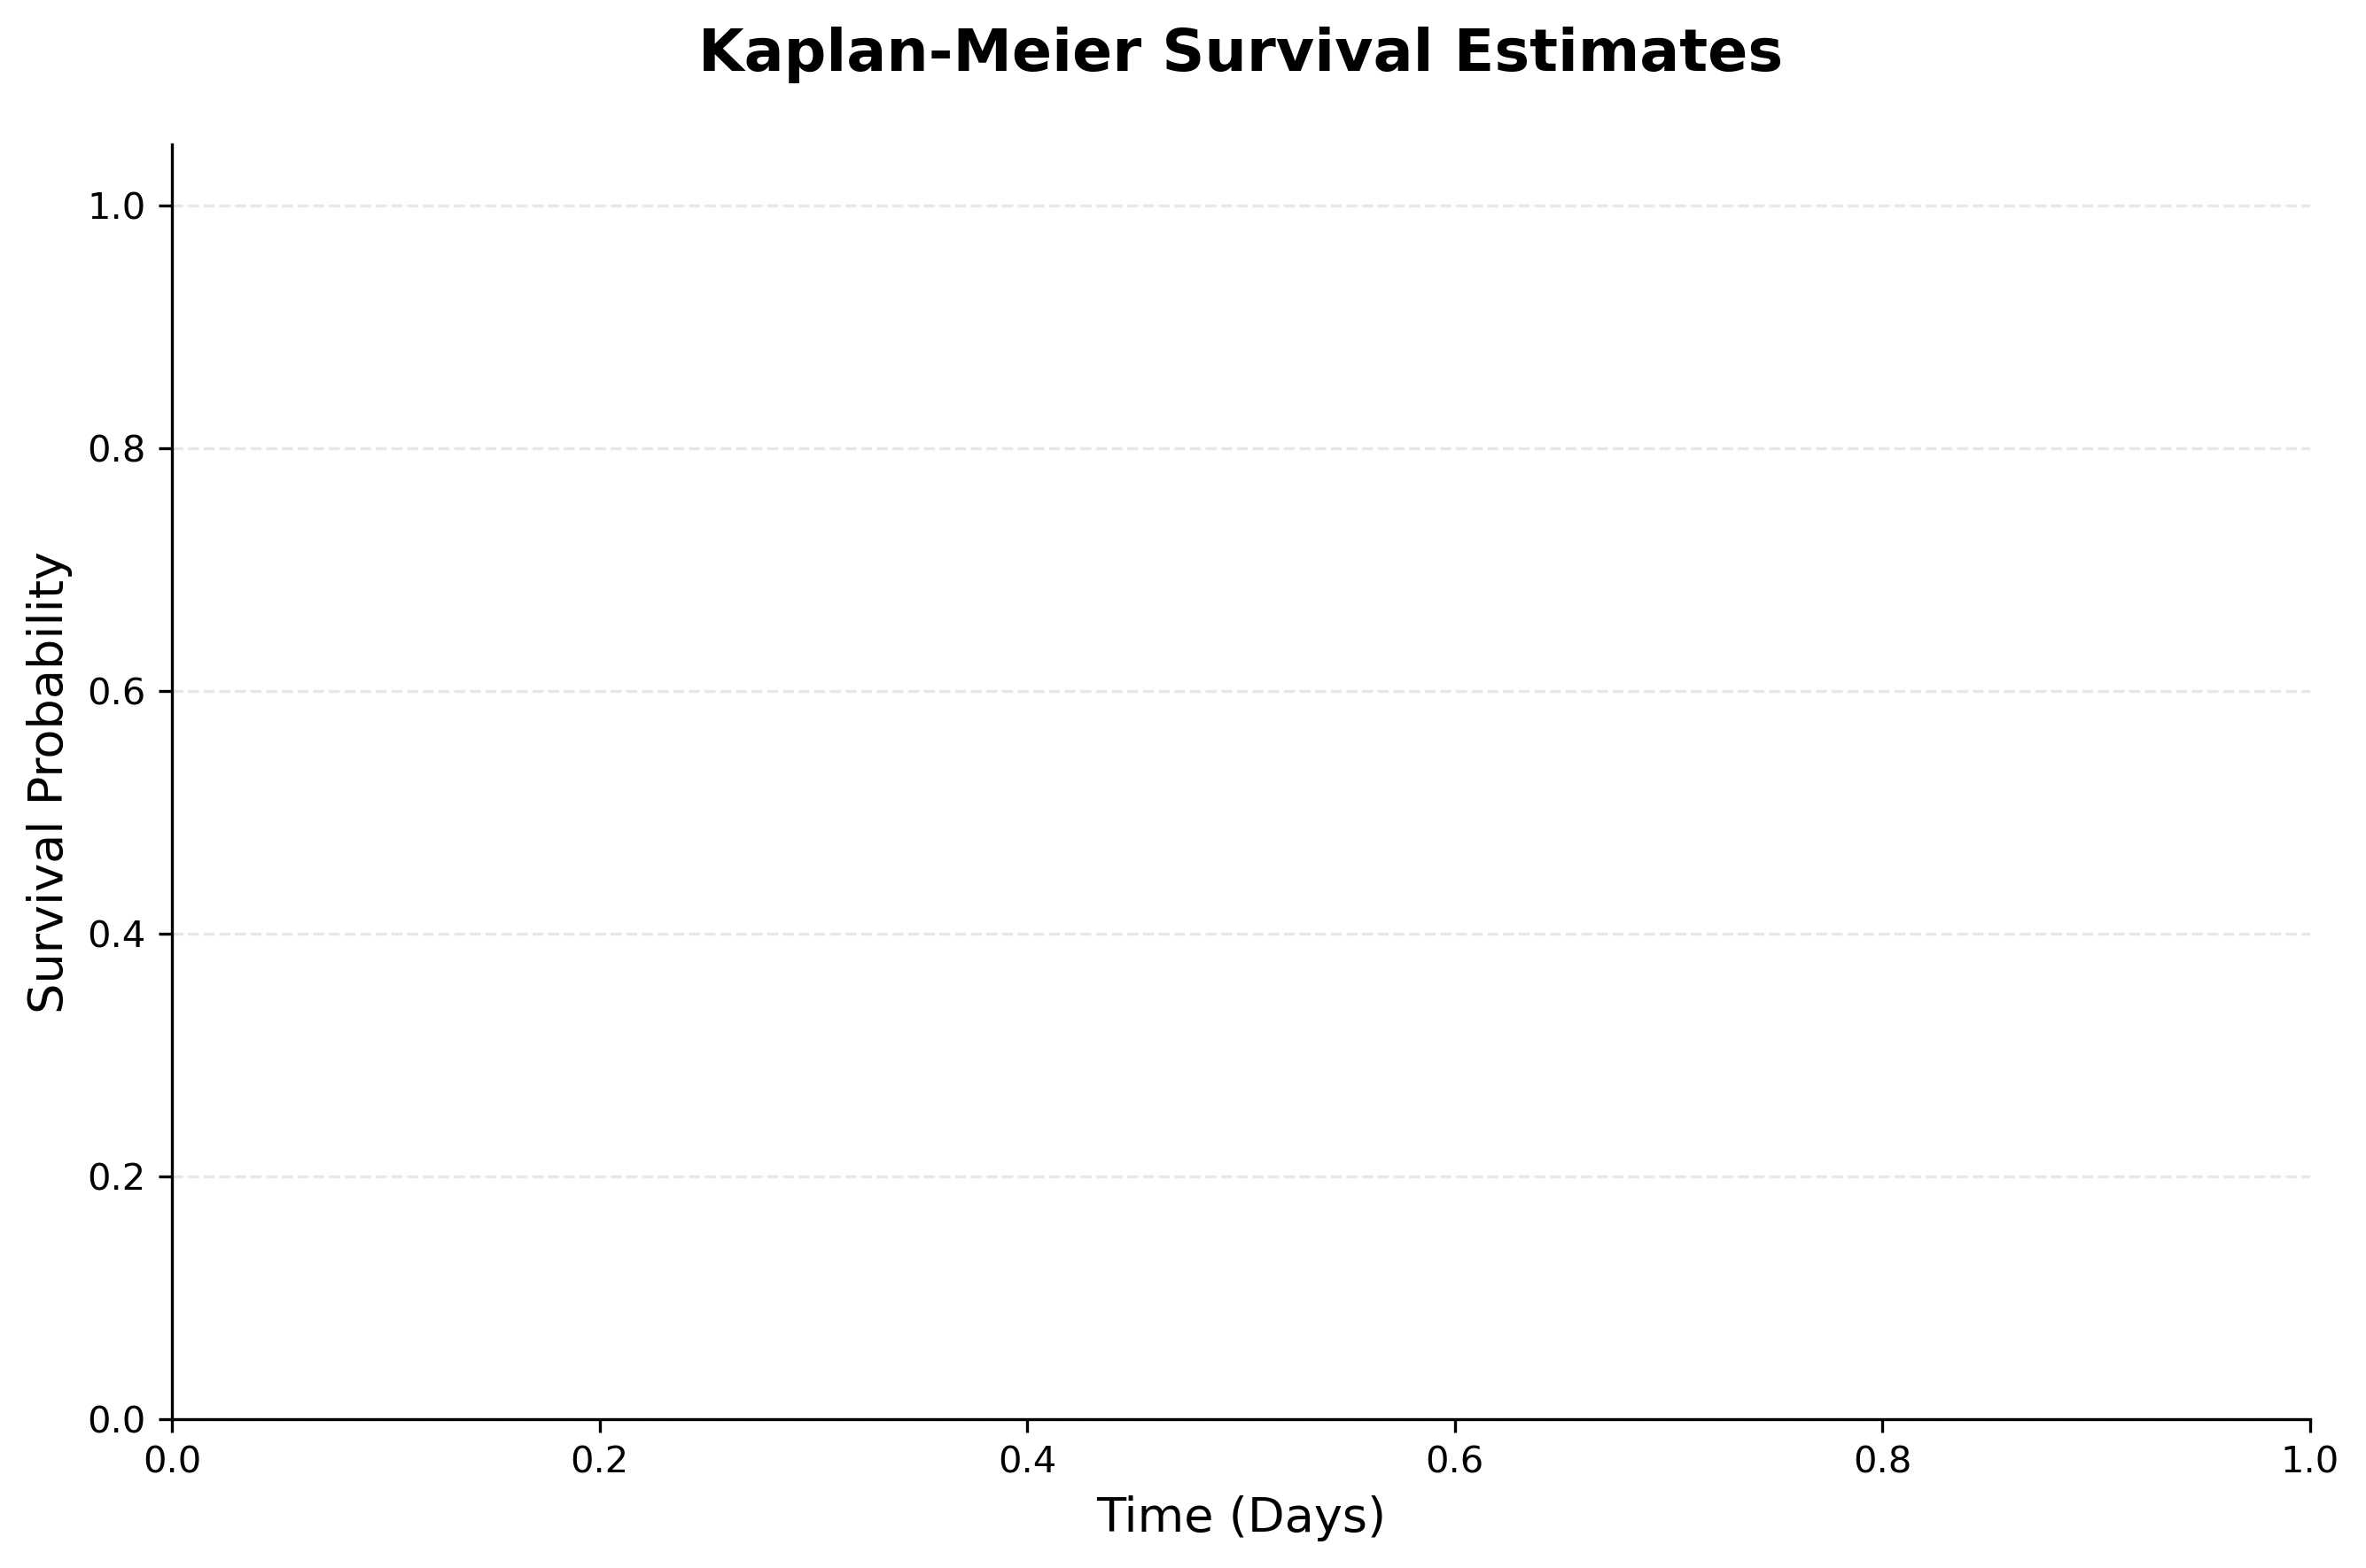

✅ 修复版 KM 曲线已生成！
路径: /home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/KM_Survival_Curve_Fixed.png


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import os

def plot_km_survival(csv_path):
    if not os.path.exists(csv_path):
        print(f"❌ 找不到文件: {csv_path}")
        return
    df = pd.read_csv(csv_path)
    
    T = df['Survival.time']
    E = df['deadstatus.event']
    groups = df['Risk_Group']
    
    plt.figure(figsize=(9, 6), dpi=300)
    ax = plt.gca() 
    kmf = KaplanMeierFitter()
    
    group_configs = [
        {'name': 'Low Risk', 'color': '#2878b5'}, 
        {'name': 'High Risk', 'color': '#c82423'}
    ]
    
    for config in group_configs:
        mask = (groups == config['name'])
        if mask.any():
            # 1. 拟合
            kmf.fit(T[mask], event_observed=E[mask], label=config['name'])
            
            # 2. 绘制曲线（关闭 show_censored 避免报错）
            kmf.plot_survival_function(
                ax=ax, 
                color=config['color'], 
                lw=2.5, 
                # show_censored=False, # <--- 彻底关闭内置绘制，解决报错
                ci_show=True, 
                ci_alpha=0.15
            )
            
            # 3. 手动绘制删失点 (Censored Data)
            # 筛选出该组中 Event=0 的点
            censored_mask = mask & (E == 0)
            if censored_mask.any():
                # 获取曲线上的生存概率值
                surv_func = kmf.survival_function_
                censored_times = T[censored_mask]
                # 在对应的时间点找到生存率并打上 '+' 号
                for t in censored_times:
                    # 找到最接近 t 的索引值
                    prob = surv_func.loc[:t].iloc[-1, 0]
                    ax.scatter(t, prob, marker='+', color=config['color'], s=60, linewidths=1, zorder=3)

    # 5. 计算 Log-rank Test
    low_mask = (groups == 'Low Risk')
    high_mask = (groups == 'High Risk')
    if low_mask.any() and high_mask.any():
        results = logrank_test(T[low_mask], T[high_mask], 
                               event_observed_A=E[low_mask], event_observed_B=E[high_mask])
        p_value = results.p_value
        p_str = f"P < 0.0001" if p_value < 0.0001 else f"P = {p_value:.4f}"
        ax.text(0.05, 0.1, f'Log-rank {p_str}', transform=ax.transAxes, 
                fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

    # 6. 图表美化
    plt.title('Kaplan-Meier Survival Estimates', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Time (Days)', fontsize=13)
    plt.ylabel('Survival Probability', fontsize=13)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.legend(frameon=False, fontsize=12)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    plt.tight_layout()
    save_path = "/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/KM_Survival_Curve_Fixed.png"
    plt.savefig(save_path, dpi=600,bbox_inches='tight')
    plt.show()
    print(f"✅ 修复版 KM 曲线已生成！\n路径: {os.path.abspath(save_path)}")

if __name__ == "__main__":
    FILE_PATH = "/home/user/prognosis_lst/evaluate_model/plot/KM曲线/huaxi/final_with_risk_groups.csv"
    plot_km_survival(FILE_PATH)